# MODELO DE CLASIFICACIÓN ENFERMEDADES RELACIONADAS CON EL SUEÑO - ESTIMACIÓN DEL RIESGO DE APNEA

Al observar que la extracción de datos únicamente de fuente propia mediante el O2Ring resultaba muy costoso, se ha optado por tomar un dataset ya existente que cumple con las características que se requiere. (Dataset de kaggle)

Se tratará de generar un modelo de clasificación para la estimación del riesgo de padecer apnea del sueño u otras enfermedades relacionadas con el sueño

## 1. IMPORTACIÓN DE LIBRERÍAS

In [55]:
# 1. CARGA DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. CARGA Y EXPLORACIÓN INICIAL DE DATOS

In [56]:
# 2. CARGA Y EXPLORACIÓN INICIAL DE DATOS

# Cargar el dataset
ruta = r"C:\Users\Marina\OneDrive - Universidad de Burgos\Escritorio\TFG-Marina-Martin\datos\Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(ruta)

# Mostrar las primeras filas
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [57]:
# Información general del dataset
df.info()

# Estadísticas descriptivas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## 3. PREPROCESAMIENTO DE DATOS

In [58]:
# 3. PREPROCESAMIENTO DE DATOS

# Eliminar columnas no predictivas
df.drop(columns=['Person ID'], inplace=True)

# Separar presión arterial en dos columnas
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)
df.drop(columns=['Blood Pressure'], inplace=True)

# Codificación de variables categóricas
# One-Hot Encoding para 'Gender' y 'Occupation'
df = pd.get_dummies(df, columns=['Gender', 'Occupation'], drop_first=True)

# Label Encoding para 'BMI Category'
le = LabelEncoder()
df['BMI Category'] = le.fit_transform(df['BMI Category'])

# Variables numéricas a escalar
variables_numericas = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Daily Steps', 'Heart Rate', 'Systolic BP', 'Diastolic BP']

scaler = StandardScaler()
df[variables_numericas] = scaler.fit_transform(df[variables_numericas])

# División en variables independientes (X) y dependiente (y)
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Aplicar SMOTE solo en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


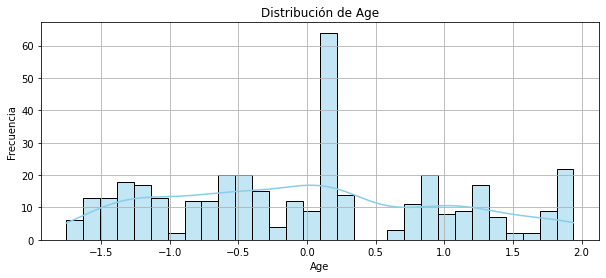

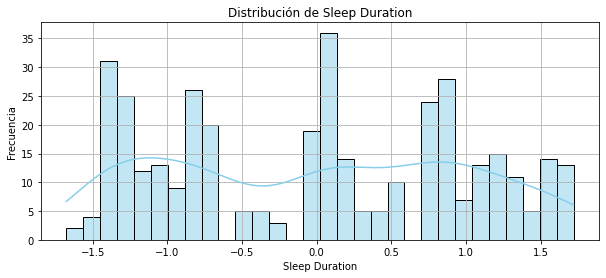

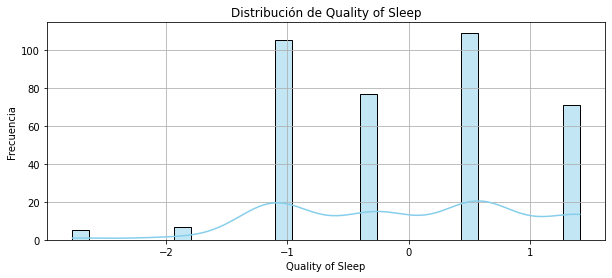

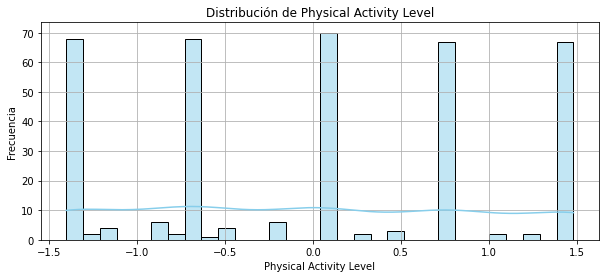

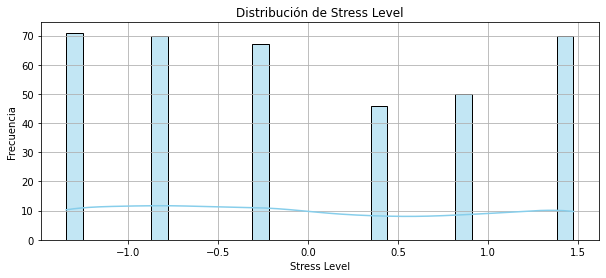

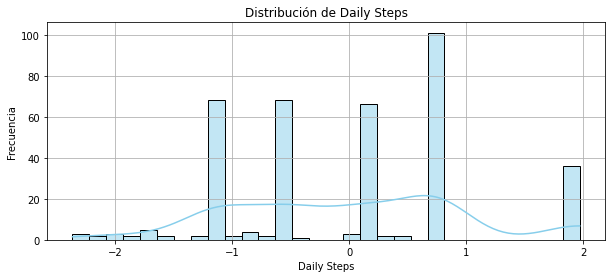

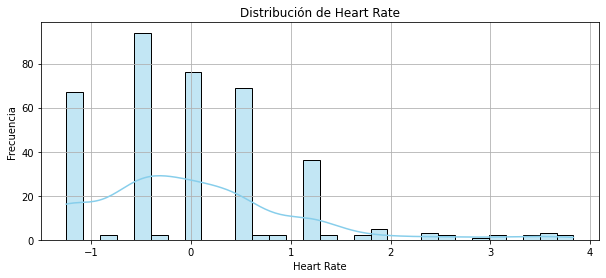

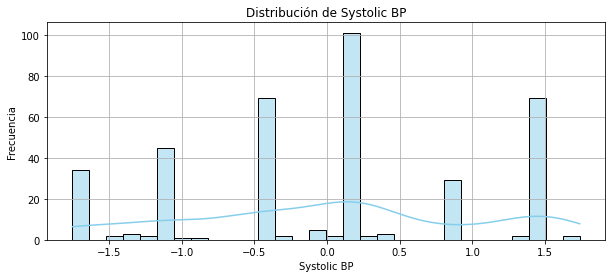

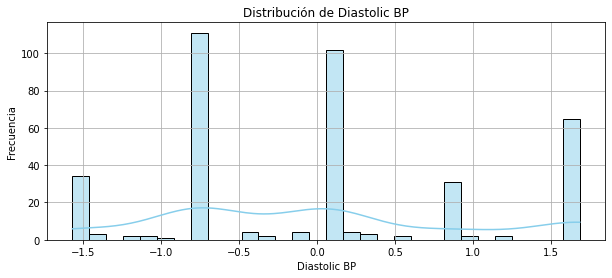

In [59]:
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

# Distribución de variables numéricas
variables_numericas = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Daily Steps', 'Heart Rate', 'Systolic BP', 'Diastolic BP']

for var in variables_numericas:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[var], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()


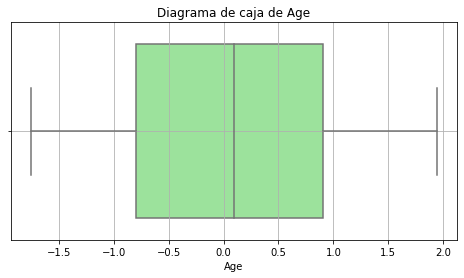

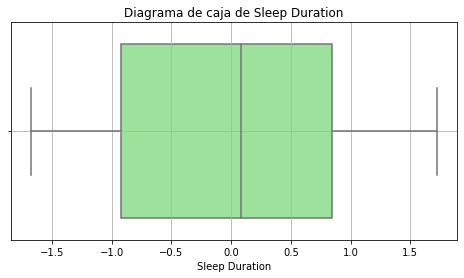

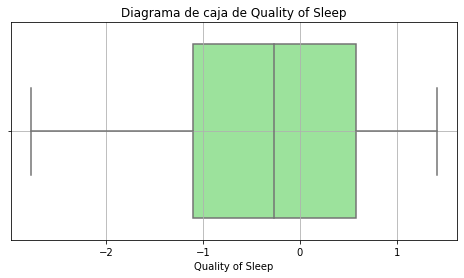

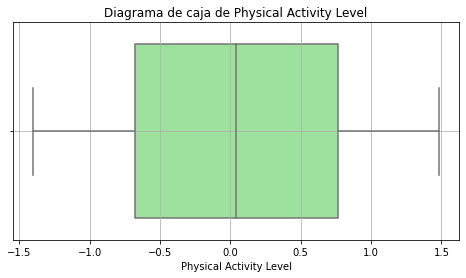

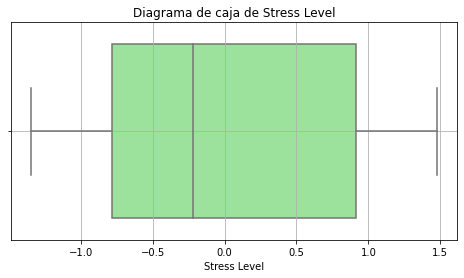

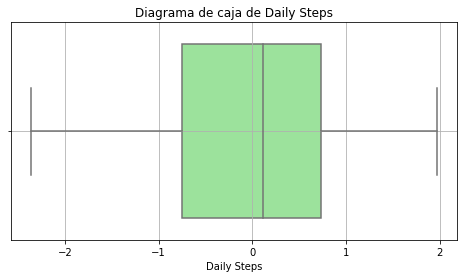

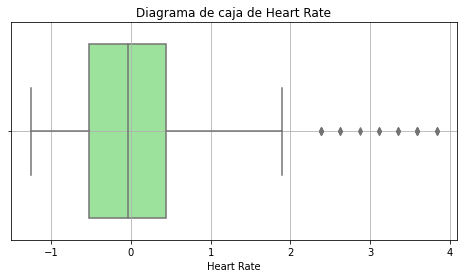

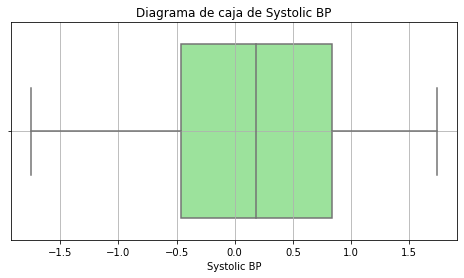

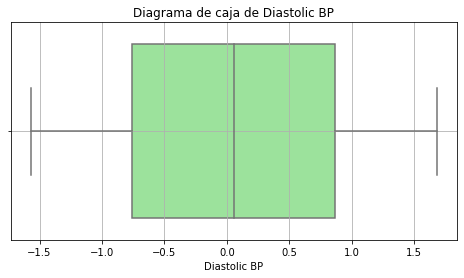

In [60]:
# Detección de outliers mediante Boxplots
for var in variables_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=var, color='lightgreen')
    plt.title(f'Diagrama de caja de {var}')
    plt.grid(True)
    plt.show()

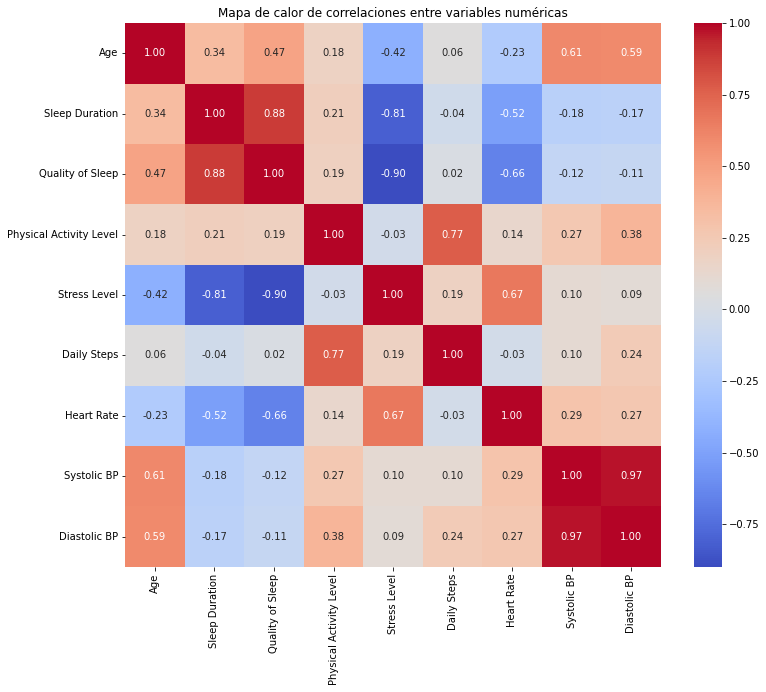

In [61]:
# Correlaciones entre variables numéricas
plt.figure(figsize=(12, 10))
correlation_matrix = df[variables_numericas].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones entre variables numéricas')
plt.show()

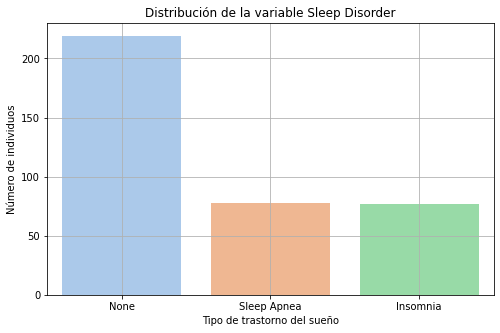

In [62]:
# Distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.countplot(x='Sleep Disorder', data=df, palette='pastel')
plt.title('Distribución de la variable Sleep Disorder')
plt.xlabel('Tipo de trastorno del sueño')
plt.ylabel('Número de individuos')
plt.grid(True)
plt.show()


## 5. ENTRENAMIENTO INICIAL Y EVALUACIÓN RÁPIDA DE MODELOS BASE (sin optimizar)

Aquí vamos a entrenar los modelos principales en su configuración estándar, evaluar su rendimiento antes de aplicar GridSearch o RandomizedSearch. Esto nos sirve como comparativa inicial.

In [63]:
# 5. ENTRENAMIENTO INICIAL Y EVALUACIÓN DE MODELOS BASE

# Definir los modelos base
modelos_base = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'MLP Classifier': MLPClassifier(max_iter=5000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Crear listas para guardar resultados
nombres_modelos = []
accuracy_modelos = []
f1_macro_modelos = []
recall_modelos = []
precision_modelos = []

from sklearn.model_selection import cross_val_score

# Evaluar modelos usando validación cruzada estratificada
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train_resampled, y_train_resampled)  # Importante usar datos SMOTEados
    y_pred = modelo.predict(X_test)
    
    # Guardar métricas
    nombres_modelos.append(nombre)
    accuracy_modelos.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')), 3))
    f1_macro_modelos.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='f1_macro')), 3))
    recall_modelos.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='recall_macro')), 3))
    precision_modelos.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='precision_macro')), 3))

# Crear un DataFrame resumen de modelos base
resultados_base = pd.DataFrame({
    'Modelo': nombres_modelos,
    'Accuracy': accuracy_modelos,
    'F1 Macro': f1_macro_modelos,
    'Recall Macro': recall_modelos,
    'Precision Macro': precision_modelos
})

# Mostrar tabla resumen
print("\nResultados de evaluación inicial de modelos base:")
display(resultados_base)



Resultados de evaluación inicial de modelos base:


,Modelo,Accuracy,F1 Macro,Recall Macro,Precision Macro
0,Logistic Regression,0.903,0.903,0.903,0.905
1,Support Vector Machine,0.897,0.897,0.897,0.900
2,Random Forest,0.907,0.907,0.907,0.908
3,MLP Classifier,0.920,0.920,0.920,0.922
4,Decision Tree,0.888,0.888,0.888,0.890


Así conseguimos:

  - Entrenar todos los modelos base en igualdad de condiciones.
  - Evaluar su rendimiento sin optimizar (solo configuraciones por defecto).
  - Crear un DataFrame resumen que te permitirá comparar después de optimizar.


Aquí usamos X_train_resampled y y_train_resampled (es decir, el dataset tras SMOTE), para que todos los modelos trabajen ya con datos balanceados

## 6. OPTIMIZACIÓN DE MODELOS (GridSearchCV / RandomizedSearchCV)

Se optimizan todos los modelos principales para que trabajen con sus **mejores combinaciones de hiperparámetros**.

Se utiliza **GridSearchCV para modelos más sencillos** (Logistic Regression, SVM, MLP, Decision Tree) y **RandomizedSearchCV para Random Forest** (por eficiencia en combinaciones posibles).

Siempre usando F1_macro como métrica principal, porque tienes clases desbalanceadas.

In [64]:
# 6. OPTIMIZACIÓN DE MODELOS

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Optimización de Logistic Regression
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42), param_grid=param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_resampled, y_train_resampled)

print("Mejores hiperparámetros Logistic Regression:", grid_lr.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [65]:
# Optimización de Support Vector Machine
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid=param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_resampled, y_train_resampled)

print("Mejores hiperparámetros SVM:", grid_svm.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [66]:
# Optimización de Random Forest (RandomizedSearchCV para ser más eficiente)
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_dist_rf, n_iter=20, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)
random_rf.fit(X_train_resampled, y_train_resampled)

print("Mejores hiperparámetros Random Forest:", random_rf.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': False}


In [67]:
# Optimización de MLP Classifier
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001]
}

grid_mlp = GridSearchCV(MLPClassifier(max_iter=5000, random_state=42), param_grid=param_grid_mlp, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_mlp.fit(X_train_resampled, y_train_resampled)

print("Mejores hiperparámetros MLP:", grid_mlp.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros MLP: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'solver': 'adam'}


In [68]:
# Optimización de Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=param_grid_dt, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_dt.fit(X_train_resampled, y_train_resampled)

print("Mejores hiperparámetros Decision Tree:", grid_dt.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros Decision Tree: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


## 7. EVALUACIÓN DE MODELOS OPTIMIZADOS y creación de tabla resumen

Gracias a la evaluación de los modelos, veremos realmente **qué modelo optimizado es el mejor** en base a:
- Accuracy
- F1 Macro
- Recall Macro
- Precision Macro

In [69]:
# 7. EVALUACIÓN DE MODELOS OPTIMIZADOS Y TABLA RESUMEN

# Definir los modelos optimizados
modelos_optim = {
    'Logistic Regression (Opt)': grid_lr.best_estimator_,
    'Support Vector Machine (Opt)': grid_svm.best_estimator_,
    'Random Forest (Opt)': random_rf.best_estimator_,
    'MLP Classifier (Opt)': grid_mlp.best_estimator_,
    'Decision Tree (Opt)': grid_dt.best_estimator_
}

# Crear listas para guardar resultados
nombres_modelos_opt = []
accuracy_opt = []
f1_macro_opt = []
recall_macro_opt = []
precision_macro_opt = []

# Evaluar cada modelo optimizado
for nombre, modelo in modelos_optim.items():
    modelo.fit(X_train_resampled, y_train_resampled)  # Entrenamos sobre los datos balanceados
    y_pred = modelo.predict(X_test)                   # Predecimos sobre el test original

    # Guardar métricas
    nombres_modelos_opt.append(nombre)
    accuracy_opt.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')), 3))
    f1_macro_opt.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='f1_macro')), 3))
    recall_macro_opt.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='recall_macro')), 3))
    precision_macro_opt.append(np.round(np.mean(cross_val_score(modelo, X_train_resampled, y_train_resampled, cv=5, scoring='precision_macro')), 3))

# Crear el DataFrame resumen
resultados_opt = pd.DataFrame({
    'Modelo Optimizado': nombres_modelos_opt,
    'Accuracy': accuracy_opt,
    'F1 Macro': f1_macro_opt,
    'Recall Macro': recall_macro_opt,
    'Precision Macro': precision_macro_opt
})

# Mostrar tabla resumen
print("\nResultados de evaluación de modelos optimizados:")
display(resultados_opt)



Resultados de evaluación de modelos optimizados:


,Modelo Optimizado,Accuracy,F1 Macro,Recall Macro,Precision Macro
0,Logistic Regression (Opt),0.912,0.913,0.912,0.917
1,Support Vector Machine (Opt),0.928,0.928,0.928,0.930
2,Random Forest (Opt),0.914,0.914,0.914,0.916
3,MLP Classifier (Opt),0.920,0.920,0.920,0.922
4,Decision Tree (Opt),0.916,0.916,0.916,0.919


## 8. EVALUACIÓN VISUAL DEL MODELO FINAL

### RANDOM FOREST

In [70]:
# 8. EVALUACIÓN VISUAL DEL MODELO FINAL

# Elegimos el modelo Random Forest optimizado
modelo_final_rf = random_rf.best_estimator_

# Entrenar de nuevo con todos los datos de entrenamiento balanceados
modelo_final_rf.fit(X_train_resampled, y_train_resampled)

# Predecir sobre el conjunto de test
y_pred_rf = modelo_final_rf.predict(X_test)
y_proba_rf = modelo_final_rf.predict_proba(X_test)

In [71]:
# Reporte de clasificación
from sklearn.metrics import classification_report

print("Reporte de clasificación del RF optimizado sobre conjunto de test:")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación del RF optimizado sobre conjunto de test:
              precision    recall  f1-score   support

    Insomnia       1.00      0.93      0.97        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.94      1.00      0.97        16

    accuracy                           0.99        75
   macro avg       0.98      0.98      0.98        75
weighted avg       0.99      0.99      0.99        75



<Figure size 504x360 with 0 Axes>

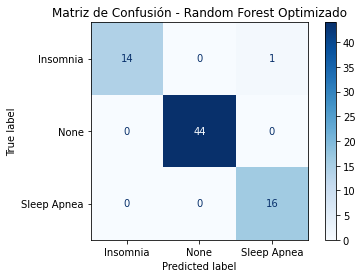

In [73]:
# Matriz de confusión
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.grid(False)
plt.show()

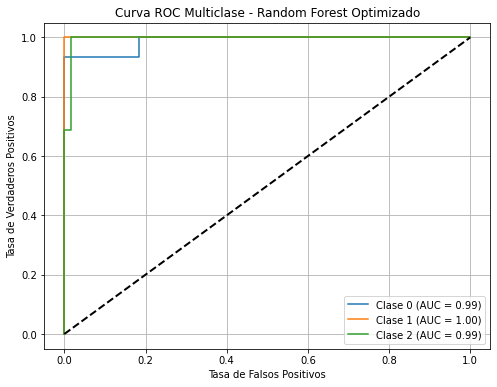

In [76]:
# Curva ROC multiclase RANDOM FOREST
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas para multiclase
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Calcular curvas ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Dibujar todas las curvas ROC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Curva ROC Multiclase - Random Forest Optimizado')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


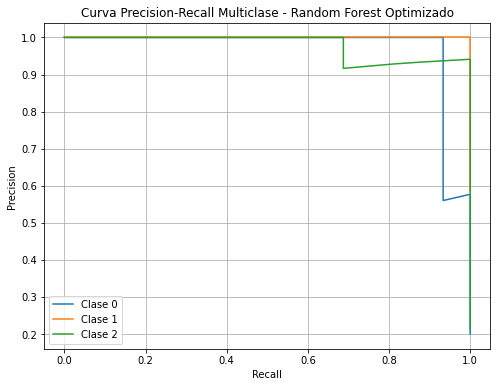

In [77]:
# Curva Precision-Recall multiclase
precision = dict()
recall = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba_rf[:, i])

# Dibujar todas las curvas Precision-Recall
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Clase {i}')
    
plt.title('Curva Precision-Recall Multiclase - Random Forest Optimizado')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## 9. INTERPRETABILIDAD DEL MODELO CON SHAP

In [79]:
# 9. INTERPRETABILIDAD DEL MODELO CON SHAP

# Cargar el explainer SHAP
explainer = shap.TreeExplainer(modelo_final_rf)  # Modelo final optimizado
shap_values = explainer.shap_values(X_test) 

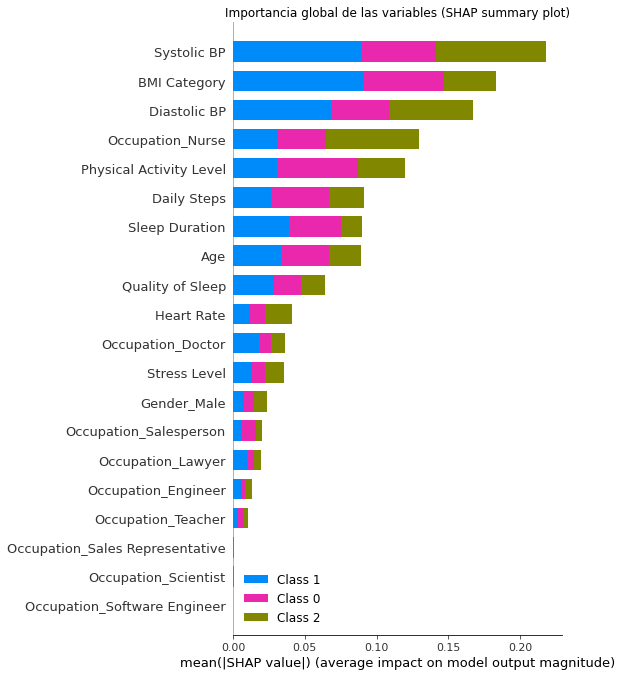

In [80]:
# Interpretabilidad global - SHAP summary plot

# Mostrar summary plot de todas las clases
plt.title('Importancia global de las variables (SHAP summary plot)')
shap.summary_plot(shap_values, X_test)

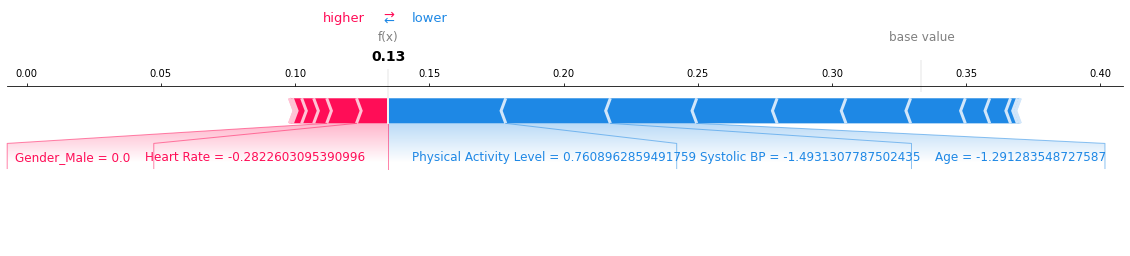

In [81]:
# Interpretabilidad individual - SHAP force plot

# Elegir una muestra aleatoria del conjunto de test
import random
random_index = random.randint(0, X_test.shape[0] - 1)

# Mostrar el force plot de esa predicción
shap.force_plot(explainer.expected_value[0], shap_values[0][random_index, :], X_test.iloc[random_index, :], matplotlib=True)

In [82]:
# 10. GUARDADO DEL MODELO FINAL OPTIMIZADO

import joblib

# Guardar el modelo final optimizado
nombre_archivo_modelo = 'modelo_random_forest_optimizado.pkl'

# Guardamos el modelo Random Forest optimizado (y calibrado si quieres aplicarlo antes)
joblib.dump(modelo_final_rf, nombre_archivo_modelo)

print(f"Modelo guardado correctamente como '{nombre_archivo_modelo}'")

Modelo guardado correctamente como 'modelo_random_forest_optimizado.pkl'


### SVM

SE PUEDE VAMBIAR EL MODELO A UNO MEJOR!!!

In [32]:
# 8. EVALUACIÓN VISUAL DEL MODELO FINAL

# Elegimos el modelo Random Forest optimizado
modelo_final_svm = grid_svm.best_estimator_

# Entrenar de nuevo con todos los datos de entrenamiento balanceados
modelo_final_svm.fit(X_train_resampled, y_train_resampled)

# Predecir sobre el conjunto de test
y_pred_svm = modelo_final_svm.predict(X_test)
y_proba_svm = modelo_final_svm.predict_proba(X_test)

In [33]:
# Reporte de clasificación
from sklearn.metrics import classification_report

print("Reporte de clasificación del SVM optimizado sobre conjunto de test:")
print(classification_report(y_test, y_pred_svm))

Reporte de clasificación del SVM optimizado sobre conjunto de test:
              precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.93      0.88      0.90        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



<Figure size 504x360 with 0 Axes>

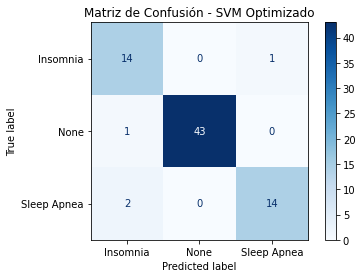

In [34]:
# Matriz de confusión
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - SVM Optimizado')
plt.grid(False)
plt.show()

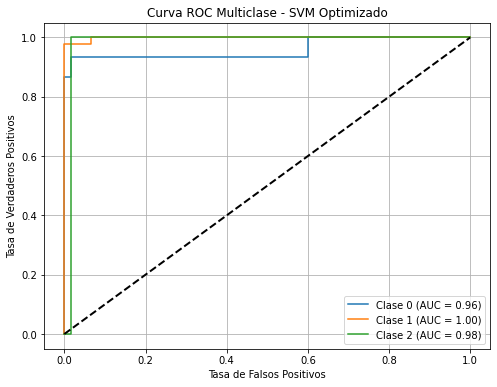

In [36]:
# Curva ROC multiclase - SVM Optimizado
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas para multiclase
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Calcular curvas ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])  # <- usar y_proba_svm
    roc_auc[i] = auc(fpr[i], tpr[i])

# Dibujar todas las curvas ROC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Curva ROC Multiclase - SVM Optimizado')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


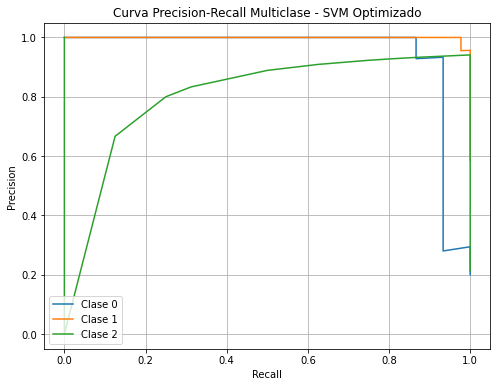

In [37]:
# Curva Precision-Recall multiclase - SVM Optimizado
precision = dict()
recall = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba_svm[:, i])  # <-- Aquí cambiamos

# Dibujar todas las curvas Precision-Recall
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Clase {i}')
    
plt.title('Curva Precision-Recall Multiclase - SVM Optimizado')  # <-- Cambiar título
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## 9. INTERPRETABILIDAD DEL MODELO CON SHAP

In [39]:
# 9. INTERPRETABILIDAD DEL MODELO CON SHAP

# Crear el explainer usando KernelExplainer
explainer_svm = shap.KernelExplainer(modelo_final_svm.predict_proba, X_train_resampled.sample(100, random_state=42))

# Calcular valores SHAP en el conjunto de test (puede tardar un poco)
shap_values_svm = explainer_svm.shap_values(X_test)

  0%|          | 0/75 [00:00<?, ?it/s]

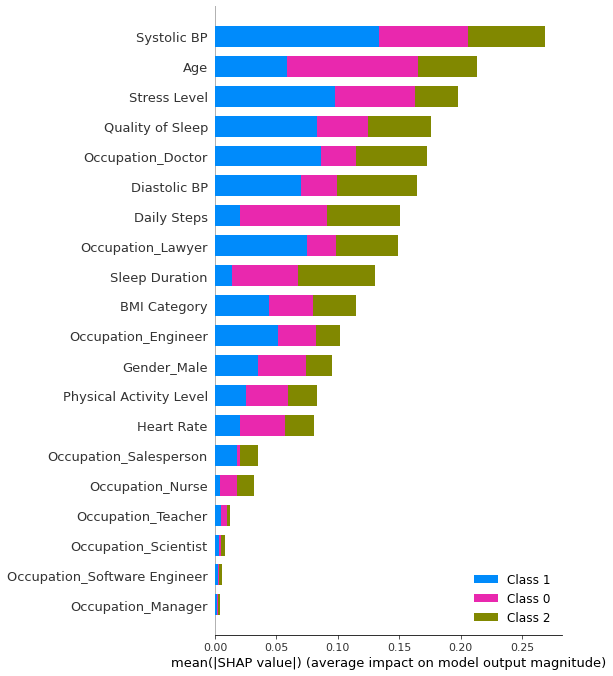

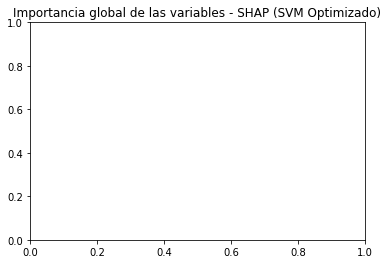

In [40]:
# SHAP Summary plot (importancia global)

shap.summary_plot(shap_values_svm, X_test, plot_type="bar")
plt.title('Importancia global de las variables - SHAP (SVM Optimizado)')
plt.show()


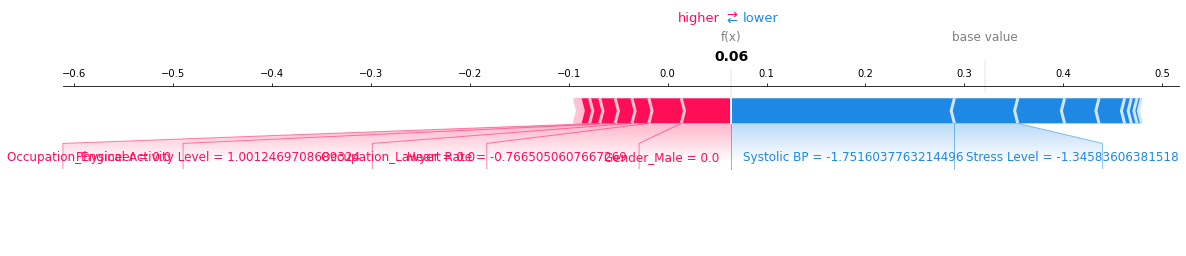

In [41]:
# SHAP Force plot (explicación de una predicción individual)

# Elegimos un ejemplo al azar del test
import random
random_index = random.randint(0, X_test.shape[0] - 1)

shap.force_plot(explainer_svm.expected_value[0], shap_values_svm[0][random_index, :], X_test.iloc[random_index, :], matplotlib=True)


In [42]:
from sklearn.calibration import CalibratedClassifierCV

modelo_svm_calibrado = CalibratedClassifierCV(base_estimator=grid_svm.best_estimator_, cv=5)
modelo_svm_calibrado.fit(X_train_resampled, y_train_resampled)

# Ahora puedes usar .predict_proba() bien
y_proba_calibrado = modelo_svm_calibrado.predict_proba(X_test)


In [44]:
# 10. GUARDADO DEL MODELO FINAL OPTIMIZADO

import joblib

# Guardar el modelo SVM optimizado
nombre_archivo_svm = 'modelo_svm_calibrado.pkl'
joblib.dump(modelo_final_svm, nombre_archivo_svm)

print(f"Modelo SVM optimizado guardado correctamente como '{nombre_archivo_svm}'")

Modelo SVM optimizado guardado correctamente como 'modelo_svm_calibrado.pkl'


In [45]:
# ===========================================
# SELECCIÓN DEL MODELO FINAL: MLP OPTIMIZADO
# ===========================================

# Cargar el mejor modelo encontrado en la optimización de MLP
modelo_final_mlp = grid_mlp.best_estimator_

# Entrenar el modelo final (por seguridad)
modelo_final_mlp.fit(X_train_resampled, y_train_resampled)

# Predicciones en el conjunto de test
y_pred_mlp = modelo_final_mlp.predict(X_test)
y_proba_mlp = modelo_final_mlp.predict_proba(X_test)  # <-- Importante para curvas ROC y Precision-Recall


Reporte de clasificación del MLP optimizado sobre conjunto de test:
              precision    recall  f1-score   support

    Insomnia       0.74      0.93      0.82        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.92        75
   macro avg       0.89      0.90      0.89        75
weighted avg       0.93      0.92      0.92        75



<Figure size 504x360 with 0 Axes>

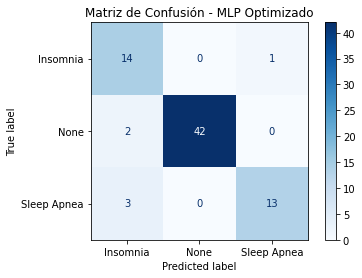

In [46]:
# EVALUACION BASICA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reporte de clasificación
print("Reporte de clasificación del MLP optimizado sobre conjunto de test:")
print(classification_report(y_test, y_pred_mlp))

# Matriz de Confusión
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - MLP Optimizado')
plt.grid(False)
plt.show()


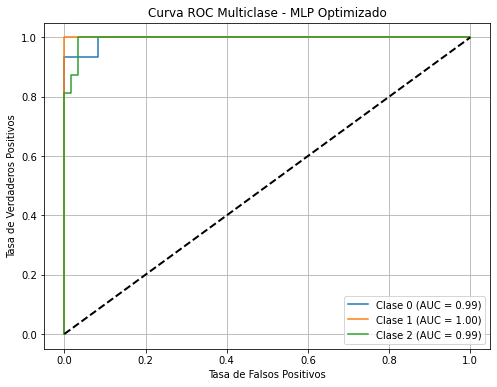

In [47]:
# CURVA ROC MULTICLASE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarizar etiquetas
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Calcular curvas ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_mlp[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Dibujar todas las curvas ROC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Curva ROC Multiclase - MLP Optimizado')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


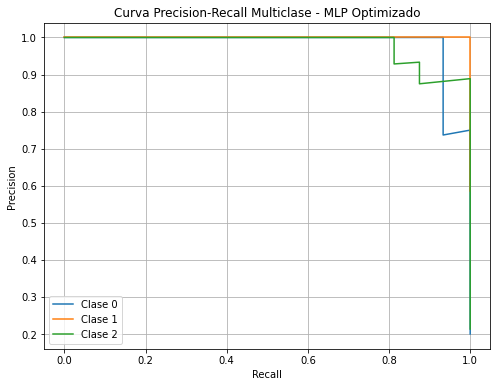

In [48]:
# CURVA PRECISION-RECALL MULTICLASE
from sklearn.metrics import precision_recall_curve

precision = dict()
recall = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba_mlp[:, i])

# Dibujar todas las curvas Precision-Recall
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Clase {i}')

plt.title('Curva Precision-Recall Multiclase - MLP Optimizado')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


In [49]:
import joblib

# Guardar el modelo final
nombre_archivo_mlp = 'modelo_mlp_optimizado.pkl'
joblib.dump(modelo_final_mlp, nombre_archivo_mlp)

print(f"Modelo MLP optimizado guardado correctamente como '{nombre_archivo_mlp}'")


Modelo MLP optimizado guardado correctamente como 'modelo_mlp_optimizado.pkl'


In [53]:
import joblib

# Definir columnas numéricas que escalaste
scaler_columns = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

# Guardar scaler + columnas juntas en un paquete
joblib.dump((scaler, scaler_columns), "scaler.pkl")


['scaler.pkl']

In [54]:
# Comprobar el contenido de scaler.pkl
cargado = joblib.load("scaler.pkl")

# Deberías ver un tuple de 2 elementos
print("Contenido de scaler.pkl:", type(cargado))
print("Número de elementos en el paquete:", len(cargado))

scaler_comprobacion, scaler_columns_comprobacion = cargado

print("Scaler cargado:", scaler_comprobacion)
print("Columnas escaladas:", scaler_columns_comprobacion)


Contenido de scaler.pkl: <class 'tuple'>
Número de elementos en el paquete: 2
Scaler cargado: StandardScaler()
Columnas escaladas: ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']


### LOGISTIC REGRESSION 

In [83]:
# ===========================================
# ENTRENAMIENTO DE LOGISTIC REGRESSION OPTIMIZADA
# ===========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import joblib

# 1. Definir el modelo base
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# 2. Definir la cuadrícula de hiperparámetros
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# 3. Configurar GridSearchCV
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  # Evaluamos con F1 Macro ya que tienes problema multiclase
    n_jobs=-1,
    verbose=2
)

# 4. Entrenar GridSearchCV sobre tu dataset
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# 5. Mejor modelo encontrado
print("Mejores hiperparámetros:", grid_log_reg.best_params_)

# 6. Guardar el modelo optimizado
joblib.dump(grid_log_reg.best_estimator_, "modelo_logistic_regression.pkl")

print("✅ Modelo Logistic Regression optimizado guardado como 'modelo_logistic_regression.pkl'")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
✅ Modelo Logistic Regression optimizado guardado como 'modelo_logistic_regression.pkl'


Se prueba Logistic Regression sin SMOTE para ver si mejora la predicción de datos reales

In [84]:
# ===========================================
# ENTRENAMIENTO DE LOGISTIC REGRESSION SIN SMOTE
# ===========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import joblib

# 1. Definir el modelo base
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# 2. Definir la cuadrícula de hiperparámetros
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# 3. Configurar GridSearchCV
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  # Evaluamos con F1 Macro para multiclase
    n_jobs=-1,
    verbose=2
)

# 4. Entrenar GridSearchCV usando SOLO X_train y y_train (SIN SMOTE)
grid_log_reg.fit(X_train, y_train)

# 5. Mejor modelo encontrado
print("Mejores hiperparámetros:", grid_log_reg.best_params_)

# 6. Guardar el mejor modelo
joblib.dump(grid_log_reg.best_estimator_, "modelo_logistic_regression_sin_smote.pkl")

print("✅ Modelo Logistic Regression sin SMOTE guardado como 'modelo_logistic_regression_sin_smote.pkl'")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
✅ Modelo Logistic Regression sin SMOTE guardado como 'modelo_logistic_regression_sin_smote.pkl'


In [85]:
# ===========================================
# SELECCIÓN DE CARACTERÍSTICAS CON SelectKBest
# ===========================================

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib

# 1. Crear selector de características
selector = SelectKBest(score_func=f_classif, k=10)  # Puedes probar k=5, 7, 10...

# 2. Modelo base
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# 3. Pipeline
pipeline = Pipeline([
    ('select', selector),
    ('clf', log_reg)
])

# 4. GridSearch (con regularización fuerte para evitar overfitting)
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['liblinear', 'saga']
}

# 5. GridSearchCV sin SMOTE, sobre tus X_train, y_train reales
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

# 6. Entrenar
grid.fit(X_train, y_train)

# 7. Ver mejores parámetros
print("Mejores parámetros:", grid.best_params_)

# 8. Guardar el mejor modelo
joblib.dump(grid.best_estimator_, "modelo_logistic_kbest.pkl")
print("✅ Guardado como 'modelo_logistic_kbest.pkl'")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
✅ Guardado como 'modelo_logistic_kbest.pkl'


In [86]:
# ===========================================
# SELECCIÓN DE CARACTERÍSTICAS CON RANDOM FOREST
# ===========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib

# 1. Random Forest como selector
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SelectFromModel(estimator=rf_selector, threshold="median", prefit=False)  # puedes ajustar el threshold

# 2. Modelo base final (puedes usar otro, pero seguimos con Random Forest)
rf_final = RandomForestClassifier(random_state=42)

# 3. Pipeline: selección + modelo
pipeline = Pipeline([
    ('select', selector),
    ('clf', rf_final)
])

# 4. Hiperparámetros (simples para probar)
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 5, 10],
    'clf__min_samples_leaf': [1, 2]
}

# 5. Entrenar sobre X_train y y_train (sin SMOTE)
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

# 6. Mejor modelo
print("Mejores hiperparámetros:", grid.best_params_)

# 7. Guardar el mejor modelo
joblib.dump(grid.best_estimator_, "modelo_rf_seleccionado.pkl")
print("✅ Guardado como 'modelo_rf_seleccionado.pkl'")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
✅ Guardado como 'modelo_rf_seleccionado.pkl'
